In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("yield_df.csv")

In [3]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
print(df.shape)

(28242, 8)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [6]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
Area,0
Item,0
Year,0
hg/ha_yield,0
average_rain_fall_mm_per_year,0
pesticides_tonnes,0
avg_temp,0


In [8]:
df = df.drop(columns=['Unnamed: 0'])

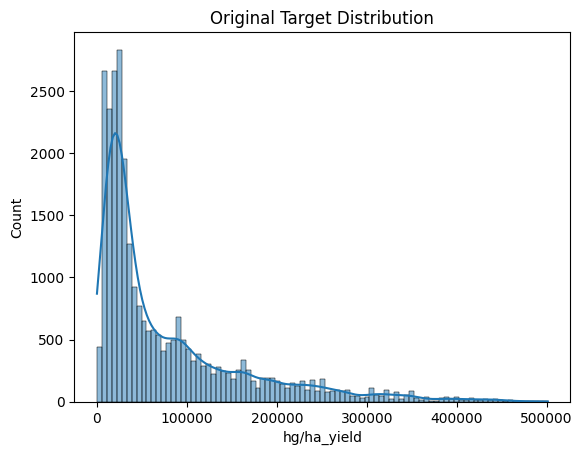

Skewness: 1.7932285390815392


In [9]:
sns.histplot(df['hg/ha_yield'], kde=True)
plt.title("Original Target Distribution")
plt.show()

print("Skewness:", df['hg/ha_yield'].skew())

In [10]:
df['yield'] = np.log1p(df['hg/ha_yield'])

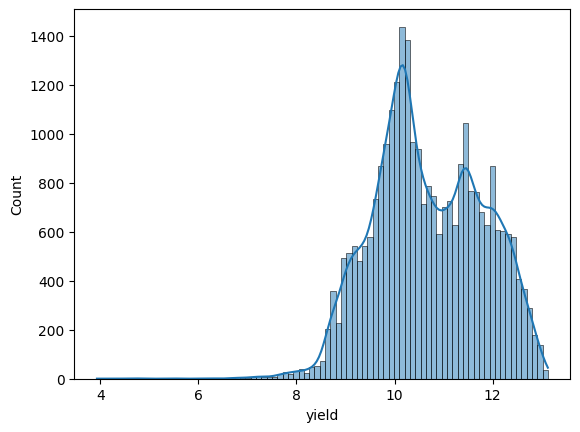

In [11]:
sns.histplot(df['yield'],kde = True)
plt.show()

In [12]:
print("Skewness after log:", df['yield'].skew())

Skewness after log: -0.04822654179377809


In [13]:
df = df.drop(columns=['hg/ha_yield'])

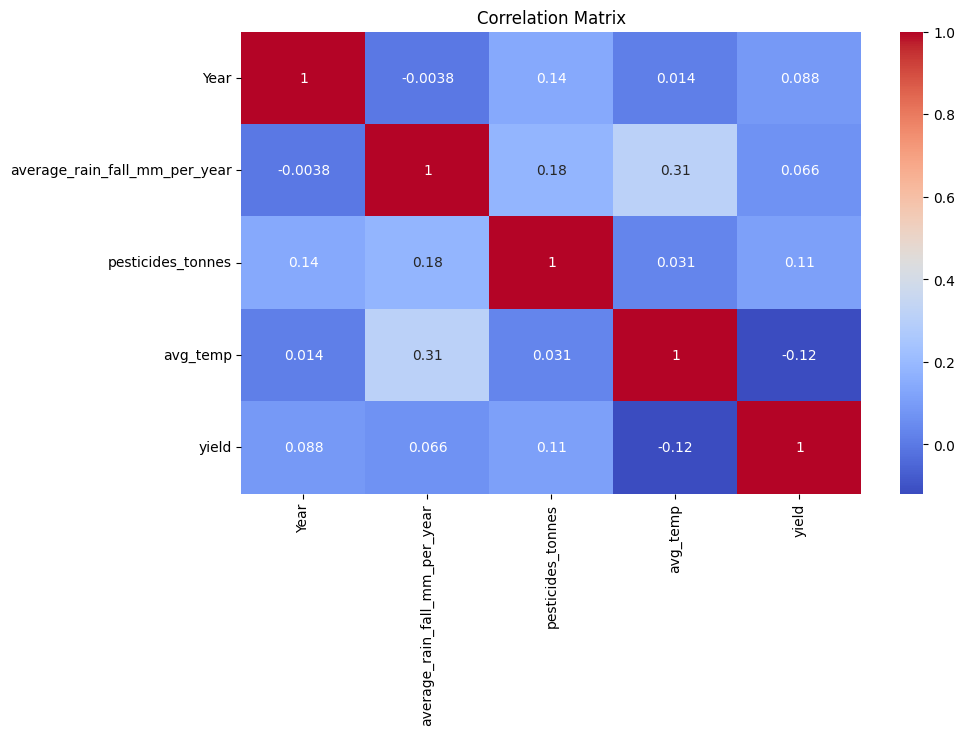

In [14]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [15]:
corr['yield'].sort_values(ascending=False)

,yield
yield,1.000000
pesticides_tonnes,0.109948
Year,0.088259
average_rain_fall_mm_per_year,0.065939
avg_temp,-0.118732


In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_cols = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

cat_cols = ["Area", "Item"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ]
)


In [17]:
X = df.drop(columns=['yield'])
y = df['yield']


In [18]:
from sklearn.linear_model import Ridge, RidgeCV


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
from sklearn.model_selection import GridSearchCV

alphas = [0.1, 1, 5, 10, 20, 50, 100, 200]
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {'model__alpha': alphas}
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_pipeline = grid.best_estimator_
best_alpha = grid.best_params_['model__alpha']
print('Best alpha:', best_alpha)

y_pred = best_pipeline.predict(X_test)


Best alpha: 0.1


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('MAE :', round(mae, 4))
print('RMSE:', round(rmse, 4))
print('R2  :', round(r2, 4))

MAE : 0.3389
RMSE: 0.45
R2  : 0.8347


In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(cv_scores)

[0.65377151 0.43555066 0.84149674 0.69133951 0.59466273]


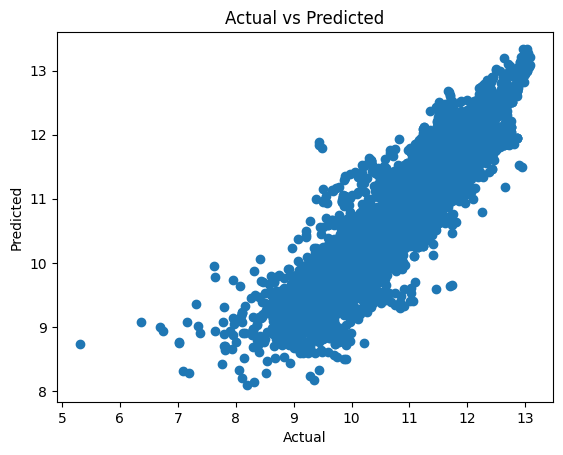

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

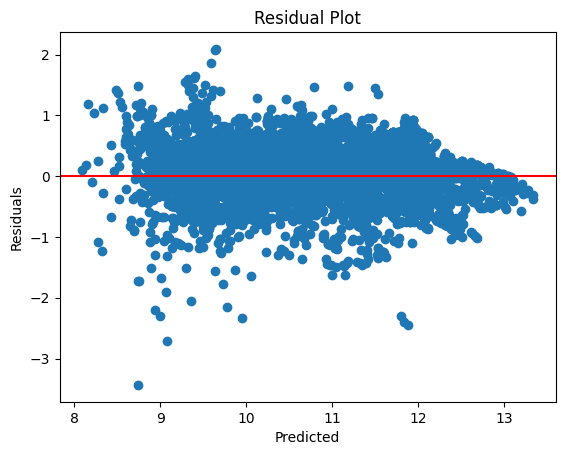

In [24]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [25]:
test_cases = pd.DataFrame([
    {
        "Area": "India",
        "Item": "Rice, paddy",
        "Year": 2020,
        "average_rain_fall_mm_per_year": 1083.0,
        "pesticides_tonnes": 50000.0,
        "avg_temp": 26.5
    },
    {
        "Area": "India",
        "Item": "Maize",
        "Year": 2020,
        "average_rain_fall_mm_per_year": 1083.0,
        "pesticides_tonnes": 50000.0,
        "avg_temp": 26.5
    },
    {
        "Area": "Albania",
        "Item": "Potatoes",
        "Year": 1990,
        "average_rain_fall_mm_per_year": 1485.0,
        "pesticides_tonnes": 121.0,
        "avg_temp": 16.37
    }
])

predictions = best_pipeline.predict(test_cases)

predictions = np.expm1(predictions)

for i, pred in enumerate(predictions, start=1):
    print(f"Test Case {i}")
    print(f"Predicted Crop Yield: {pred:.2f} hg/ha")
    print()

Test Case 1
Predicted Crop Yield: 44820.44 hg/ha

Test Case 2
Predicted Crop Yield: 32612.61 hg/ha

Test Case 3
Predicted Crop Yield: 150746.64 hg/ha

